In [1]:
import itertools
from collections import defaultdict
from typing import Any, List, Optional, Sequence, Union

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ALPHABET = "ACGT"

def hamming1_neighbors(core: str, alphabet: str = ALPHABET) -> List[str]:
    nbrs = []
    for i, ch in enumerate(core):
        for a in alphabet:
            if a != ch:
                nbrs.append(core[:i] + a + core[i + 1:])
    return nbrs

## Import the cloud data and prepare the df

In [2]:
# Clusters
clusters = pd.read_csv('data/processed/clusters_with_stats.csv')
clusters.head()

,CLUSTER_,CORE REL EXPR_mean,CORE REL EXPR_std,SEQ_unique
0,0,0.129612,0.017409,"AATTTA,AATTCT,AATTCA,AACTTA,AAATCC,AATATG,AATA..."
1,1,0.229000,NaN,ATCCGC
2,2,0.123416,0.014622,"ACCTAC,ACCTCC,ACATCC,ACATCA,ACATAC,AAATCA,ATAT..."
3,3,0.052767,0.008386,"CGTTCC,CGTCCC,CGTCAC"
4,4,0.104843,0.013261,"CCGAAA,CCGAAT,CCGTGA,CTGCCT,CCGGAC,CAAGTC,CCGG..."


In [3]:
# Create new dataframe, when one column is the core sequence (splitted SEQ_unique) and the others are the cluster and mean expression
clusters_core = (
    clusters
    .assign(SEQ_unique=clusters['SEQ_unique'].str.split(','))
    .explode('SEQ_unique')
    .reset_index(drop=True)
)

clusters_core.head()

,CLUSTER_,CORE REL EXPR_mean,CORE REL EXPR_std,SEQ_unique
0,0,0.129612,0.017409,AATTTA
1,0,0.129612,0.017409,AATTCT
2,0,0.129612,0.017409,AATTCA
3,0,0.129612,0.017409,AACTTA
4,0,0.129612,0.017409,AAATCC


In [4]:
# Rename columns to the internal schema expected by the analysis below
df = (
    clusters_core
    .rename(columns={
        "CLUSTER_": "cloud",
        "CORE REL EXPR_mean": "etr",
        "SEQ_unique": "core"
    })
    .copy()
)
df = df.drop(columns=["CORE REL EXPR_std"], errors="ignore")
df.head()

,cloud,etr,core
0,0,0.129612,AATTTA
1,0,0.129612,AATTCT
2,0,0.129612,AATTCA
3,0,0.129612,AACTTA
4,0,0.129612,AAATCC


## Validation of the df

In [5]:
# Basic cleaning/validation
df["core"] = df["core"].astype(str).str.upper().str.strip()
df["etr"] = pd.to_numeric(df["etr"], errors="coerce")

# Ensure cloud is a compact label (int if possible)
try:
    df["cloud"] = pd.to_numeric(df["cloud"], errors="raise").astype(int)
except Exception:
    # keep as string if casting fails
    df["cloud"] = df["cloud"].astype(str)

# Validate cores
mask_len = df["core"].str.len() == 6
mask_alpha = df["core"].apply(lambda s: set(s) <= set(ALPHABET))
if not (mask_len & mask_alpha).all():
    bad = df.loc[~(mask_len & mask_alpha), "core"].unique().tolist()
    raise ValueError(f"Invalid cores (not 6-mers or wrong alphabet): {bad[:10]}...")

df.head()

,cloud,etr,core
0,0,0.129612,AATTTA
1,0,0.129612,AATTCT
2,0,0.129612,AATTCA
3,0,0.129612,AACTTA
4,0,0.129612,AAATCC


## Build the Hamming-1 graph over the cores

In [6]:
def build_core_graph(df: pd.DataFrame, include_all_4096: bool = False) -> nx.Graph:
    """
    Constructs a Hamming-1 graph of the SD cores.

    In a Hamming-1 graph, nodes represent SD core sequences and edges connect sequences
    that differ by exactly one nucleotide (Hamming distance of 1).

    Args:
        df: DataFrame containing columns 'core' (SD core sequence), 'etr' (their strength),
            and 'cloud' (cluster/cloud identifier).
        include_all_4096: If True, includes all possible 6-nucleotide sequences (4^6 = 4096)
                         in the graph, adding missing sequences with NaN values.

    Returns:
        A NetworkX Graph object where:
        - Nodes are DNA sequences (strings)
        - Node attributes:
            - 'etr': relative strength from input DataFrame
            - 'cloud': cluster/cloud identifier from input DataFrame
        - Edges connect sequences that are Hamming-1 neighbors
    """
    # Handle all possible 6-nucleotide sequences if requested (not our case here)
    if include_all_4096:
        # Generate all possible 6-nucleotide combinations from the DNA alphabet
        universe = set("".join(p) for p in itertools.product(ALPHABET, repeat=6))
        nodes = universe
        # If input DataFrame is missing any sequences, add them with NaN values
        if len(df) < len(universe):
            missing = list(universe - set(df["core"]))
            if missing:
                df = pd.concat(
                    [df, pd.DataFrame({"core": missing, "etr": np.nan, "cloud": np.nan})],
                    ignore_index=True
                )
    else:
        # Use only the sequences present in the input DataFrame
        nodes = set(df["core"])

    # Initialize an undirected graph
    G = nx.Graph()
    G.add_nodes_from(nodes)

    # Add node attributes from the DataFrame
    nx.set_node_attributes(G, pd.Series(df["etr"].values, index=df["core"]).to_dict(), name="etr")
    nx.set_node_attributes(G, pd.Series(df["cloud"].values, index=df["core"]).to_dict(), name="cloud")

    # Create edges between Hamming-1 neighbors
    node_set = set(G.nodes)
    edges = set()
    for c in nodes:
        # Find all sequences that are Hamming-1 neighbors of the current sequence
        for nbr in hamming1_neighbors(c):
            if nbr in node_set:  # Only add edge if neighbor exists in our node set
                # Use sorted tuple to avoid duplicate edges (since graph is undirected)
                e = (c, nbr) if c < nbr else (nbr, c)
                edges.add(e)
    G.add_edges_from(edges)
    print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G


G = build_core_graph(df, include_all_4096=False)

Graph built: 4096 nodes, 36864 edges


## Compute the intra-cloud robustness metrics

In [7]:
def compute_intra_cloud_metrics(G: nx.Graph, df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes various graph metrics for each cloud in the Hamming-1 graph.

    For each cloud (cluster) of SD core sequences, this function calculates several network metrics
    that characterize the structure and connectivity of the cloud within the Hamming-1 graph.

    Args:
        G: The complete Hamming-1 graph containing all sequences
        df: DataFrame containing 'core' (sequence) and 'cloud' (cluster ID) columns

    Returns:
        A DataFrame with one row per cloud, containing various network metrics

    Note:
        A connected component is a maximal set of those cores where every core can be reached from every other via a path of single-nt steps without leaving the cloud:
            n_components = how many separate “islands” (neutral networks) the cloud breaks into.
                A large giant component ⇒ many cores are mutationally connected within the cloud (robustness)
                Many small components ⇒ the cloud is fragmented into isolated islands.
    """
    metrics = []

    # Process each cloud (cluster) separately
    for cloud, sub in df.groupby("cloud"):
        # Get all nodes (sequences) in the current cloud
        nodes = list(sub["core"])
        # Create a subgraph containing only nodes from this cloud
        H = G.subgraph(nodes).copy()

        # Basic graph metrics
        n = H.number_of_nodes()  # Number of nodes in the cloud
        m = H.number_of_edges()  # Number of edges in the cloud
        if n == 0:  # Skip empty clouds - shouldn't be the case
            print('Empty cloud found')
            continue

        # Calculate connected components
        comps = [len(c) for c in nx.connected_components(H)]
        giant = max(comps) if comps else 0  # Size of the largest connected component
        giant_frac = giant / n if n else np.nan  # Fraction of nodes in the giant component

        # Network topology metrics
        avg_deg = 2 * m / n if n else 0.0  # Average degree (2*edges/nodes for undirected graph)
        avg_clust = nx.average_clustering(H) if n > 1 else 0.0  # Clustering coefficient

        # Calculate average shortest path length on the giant component
        if giant >= 2:  # Need at least 2 nodes for a path
            H_giant = H.subgraph(max(nx.connected_components(H), key=len))
            try:
                asp = nx.average_shortest_path_length(H_giant)
            except Exception:  # Handle disconnected components
                asp = np.nan
        else:
            asp = np.nan

        # Compile all metrics for this cloud
        metrics.append({
            "cloud": cloud,  # Cloud identifier
            "n_nodes": n,  # Total number of nodes in the cloud
            "n_edges": m,  # Total number of edges in the cloud
            "n_components": len(comps),  # Number of connected components
            "giant_component_size": giant,  # Size of the largest connected component
            "giant_component_fraction": giant_frac,  # Fraction of nodes in the giant component
            "avg_degree": avg_deg,  # Average node degree
            "average_clustering": avg_clust,  # Clustering coefficient
            "average_shortest_path_on_giant": asp,  # ASP on the giant component
            "mean_cloud_etr": sub["etr"].mean()  # Mean enhancer activity in the cloud
        })

    # Convert the list of metrics to a DataFrame, sorted by cloud ID
    return pd.DataFrame(metrics).sort_values("cloud")


intra_df = compute_intra_cloud_metrics(G, df)
intra_df

,cloud,n_nodes,n_edges,n_components,giant_component_size,giant_component_fraction,avg_degree,average_clustering,average_shortest_path_on_giant,mean_cloud_etr
0,0,17,6,11,5,0.294118,0.705882,0.000000,2.000000,0.129612
1,1,1,0,1,1,1.000000,0.000000,0.000000,NaN,0.229000
2,2,67,80,14,49,0.731343,2.388060,0.140299,4.627551,0.123416
3,3,3,2,1,3,1.000000,1.333333,0.000000,1.333333,0.052767
4,4,14,8,7,7,0.500000,1.142857,0.059524,1.904762,0.104843
...,...,...,...,...,...,...,...,...,...,...
376,376,3,1,2,2,0.666667,0.666667,0.000000,1.000000,0.070700
377,377,43,49,12,18,0.418605,2.279070,0.197231,2.313725,0.103400
378,378,68,114,5,63,0.926471,3.352941,0.175712,4.118280,0.081756
379,379,4,0,4,1,0.250000,0.000000,0.000000,NaN,0.130325


## Inter-cloud meta-graph and transition matrices creation

In [8]:
def build_intercloud_graph_and_transitions(
        G: nx.Graph, df: pd.DataFrame
):
    """
    Analyzes transitions between different clouds in the Hamming-1 graph.

    This function:
    1. Counts all possible moves between clouds
    2. Identifies beneficial moves (where ETR increases)
    3. Builds a meta-graph where nodes are clouds and edges represent transitions
    4. Computes transition probability and benefit matrices

    Args:
        G: The complete Hamming-1 graph
        df: DataFrame containing 'core', 'cloud', and 'etr' columns

    Returns:
        tuple: (H_cloud, meta_edges_df, T_prob_df, T_benef_df)
            - H_cloud: Meta-graph where nodes are clouds and edges represent transitions
            - meta_edges_df: DataFrame with edge information between clouds
            - T_prob_df: Transition probability matrix between clouds
            - T_benef_df: Matrix of beneficial transition probabilities
    """
    # Create mappings for quick lookups
    core_to_cloud = pd.Series(df["cloud"].values, index=df["core"]).to_dict()
    core_to_etr = pd.Series(df["etr"].values, index=df["core"]).to_dict()

    # Initialize counters and trackers
    move_counts = defaultdict(int)  # Counts of all moves between clouds
    beneficial_counts = defaultdict(int)  # Counts of beneficial moves (ETR increasing)
    bridge_pairs = defaultdict(list)  # Tracks ETR differences for each cloud pair
    seen_pairs = set()  # Prevents double-counting undirected edges

    # Analyze all edges in the Hamming-1 graph
    for u, v in G.edges():
        cu, cv = core_to_cloud.get(u), core_to_cloud.get(v)
        eu, ev = core_to_etr.get(u), core_to_etr.get(v)

        # Count all moves between clouds (in both directions)
        if cu is not None and cv is not None:
            move_counts[(cu, cv)] += 1
            move_counts[(cv, cu)] += 1
            # Track beneficial moves (where ETR increases)
            if all(x is not None and np.isfinite(x) for x in (eu, ev)):
                if ev > eu: beneficial_counts[(cu, cv)] += 1
                if eu > ev: beneficial_counts[(cv, cu)] += 1

        # Track ETR differences for cloud pairs (for meta-graph edges)
        if cu is not None and cv is not None and cu != cv:
            key_pair = tuple(sorted((u, v)))
            if key_pair not in seen_pairs:
                seen_pairs.add(key_pair)
                key_cloud = tuple(sorted((cu, cv)))
                if all(x is not None and np.isfinite(x) for x in (eu, ev)):
                    bridge_pairs[key_cloud].append(abs(ev - eu))
                else:
                    bridge_pairs[key_cloud].append(np.nan)

    # Create transition matrices
    clouds = sorted(df["cloud"].dropna().unique().tolist())
    idx = {c: i for i, c in enumerate(clouds)}
    T_prob = np.zeros((len(clouds), len(clouds)), float)  # Transition probabilities
    T_benef = np.full((len(clouds), len(clouds)), np.nan, float)  # Benefit probabilities

    # Fill transition and benefit matrices
    for (c_from, c_to), cnt in move_counts.items():
        i, j = idx[c_from], idx[c_to]
        T_prob[i, j] += cnt
        b = beneficial_counts.get((c_from, c_to), 0)
        T_benef[i, j] = b / cnt if cnt > 0 else np.nan

    # Normalize transition probabilities
    row_sums = T_prob.sum(axis=1, keepdims=True)
    T_prob = np.where(row_sums > 0, T_prob / row_sums, 0.0)

    # Convert to DataFrames with proper labels

    # Row-stochastic transition probabilities between clouds:
    # rows = origin cloud, columns = destination cloud; each row sums to ~1.0.
    # Entry (i, j) = P(random 1-nt mutation from a core in cloud_i lands in cloud_j).
    T_prob_df = pd.DataFrame(T_prob, index=clouds, columns=clouds)

    # Fraction of *beneficial* moves between clouds:
    # Entry (i, j) = fraction of 1-nt neighbor moves from cloud_i to cloud_j with ΔETR > 0.
    # Diagonal gives fraction of within-cloud moves that improve ETR; off-diagonals show
    # how often a step into another cloud increases ETR.
    T_benef_df = pd.DataFrame(T_benef, index=clouds, columns=clouds)

    # Build the meta-graph where nodes are clouds
    H_cloud = nx.Graph()
    # Add nodes with size attribute (number of sequences in each cloud)
    for c in clouds:
        H_cloud.add_node(c, size=int((df["cloud"] == c).sum()))

    # Process edges between clouds
    meta_rows = []
    for (ca, cb), deltas in bridge_pairs.items():
        vals = np.array(deltas, float)
        bridge_count = len(vals)  # Number of edges between these clouds
        mean_abs_delta = np.nanmean(vals) if bridge_count else np.nan

        # Add edge to meta-graph with attributes
        H_cloud.add_edge(
            ca, cb,
            bridge_count=bridge_count,
            mean_abs_delta_etr=mean_abs_delta
        )

        # Record edge information
        meta_rows.append({
            "cloud_u": ca,  # Origin cloud
            "cloud_v": cb,  # Destination cloud
            "bridge_count": bridge_count,  # How many unique, undirected “bridges” exist between the two clouds
            "mean_abs_delta_etr": mean_abs_delta
            # The mean absolute difference in ETR across all bridges between the two clouds
        })

    # Create DataFrame of meta-edges
    meta_edges_df = (pd.DataFrame(meta_rows)
                     .sort_values(["cloud_u", "cloud_v"])
                     .reset_index(drop=True))

    return H_cloud, meta_edges_df, T_prob_df, T_benef_df

In [9]:
H_cloud, meta_edges_df, T_prob_df, T_benef_df = build_intercloud_graph_and_transitions(G, df)
meta_edges_df

,cloud_u,cloud_v,bridge_count,mean_abs_delta_etr
0,0,1,3,0.099388
1,0,2,35,0.006195
2,0,5,4,0.049655
3,0,7,3,0.189038
4,0,23,1,0.044118
...,...,...,...,...
11586,377,378,51,0.021644
11587,377,379,3,0.026925
11588,377,380,16,0.012764
11589,378,379,13,0.048569


In [10]:
# Transition probabilities (row sums ≈ 1.0) - how it is probable, that single mutation in the starting cloud will lead to the destination cloud
T_prob_df  # P(cloud_i -> cloud_j)

,0,1,2,3,4,5,6,7,8,9,...,371,372,373,374,375,376,377,378,379,380
0,0.039216,0.009804,0.114379,0.000000,0.000000,0.013072,0.000000,0.009804,0.000000,0.0,...,0.006536,0.000000,0.006536,0.000000,0.003268,0.000000,0.009804,0.029412,0.003268,0.003268
1,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.029022,0.000000,0.132670,0.000000,0.000829,0.000829,0.000000,0.000829,0.002488,0.0,...,0.007463,0.000829,0.001658,0.000000,0.018242,0.000000,0.011609,0.020730,0.002488,0.008292
3,0.000000,0.000000,0.000000,0.074074,0.000000,0.037037,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.003968,0.000000,0.063492,0.027778,0.003968,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011905,0.011905,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.037037,0.037037,0.000000,0.037037,0.000000,0.000000,0.000000,0.000000
377,0.003876,0.000000,0.018088,0.000000,0.003876,0.010336,0.002584,0.001292,0.000000,0.0,...,0.003876,0.000000,0.005168,0.000000,0.002584,0.000000,0.126615,0.065891,0.003876,0.020672
378,0.007353,0.000000,0.020425,0.000000,0.002451,0.013072,0.000817,0.000817,0.000817,0.0,...,0.000817,0.000000,0.001634,0.000000,0.000817,0.000000,0.041667,0.186275,0.010621,0.009804
379,0.013889,0.000000,0.041667,0.000000,0.000000,0.027778,0.000000,0.000000,0.013889,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.041667,0.180556,0.000000,0.000000


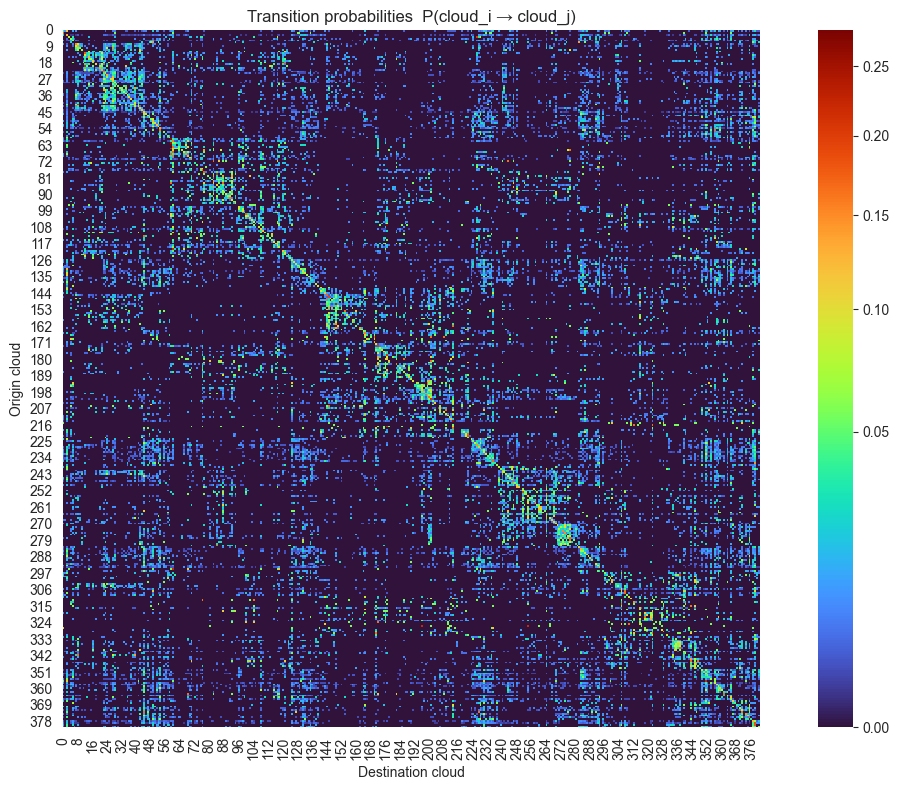

In [11]:
def plot_Tprob_heatmap(T_prob_df: pd.DataFrame, title="Transition probabilities  P(cloud_i → cloud_j)",
                       annot=False, fmt=".2f", cmap="turbo", savepath=None):
    """
    Row-stochastic heatmap: rows=sum≈1.0. Diagonal = P(stay), off-diagonals = P(leave to that cloud).
    """
    # Ensure numeric
    mat = T_prob_df.astype(float).copy()

    plt.figure(figsize=(12, 8))
    norm = mcolors.PowerNorm(gamma=0.5)  # <1 stretches small differences
    ax = sns.heatmap(
        mat,
        cmap=cmap,
        square=True, cbar=True,
        norm=norm,
        annot=annot, fmt=fmt if annot else "",
    )
    ax.set_title(title)
    ax.set_xlabel("Destination cloud")
    ax.set_ylabel("Origin cloud")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, format="eps", dpi=200)
    plt.show()

plot_Tprob_heatmap(T_prob_df, annot=False)

In [12]:
# Probability of staying within the same cloud
stay_probs = np.diag(T_prob_df.values)
pd.Series(stay_probs, index=T_prob_df.index, name="P(stay)").to_frame()

,P(stay)
0,0.039216
1,0.000000
2,0.132670
3,0.074074
4,0.063492
...,...
376,0.037037
377,0.126615
378,0.186275
379,0.000000


In [13]:
# Probability of leaving (1 - stay)
leave_probs = 1 - stay_probs
pd.Series(leave_probs, index=T_prob_df.index, name="P(leave)").to_frame()

,P(leave)
0,0.960784
1,1.000000
2,0.867330
3,0.925926
4,0.936508
...,...
376,0.962963
377,0.873385
378,0.813725
379,1.000000


In [14]:
# Where do mutations go when they leave? Top 3 destinations per origin cloud:
top3_moves = (
    T_prob_df.mask(np.eye(len(T_prob_df), dtype=bool))  # mask diagonal
    .apply(lambda row: row.sort_values(ascending=False).head(3), axis=1)
)
top3_moves

,0,2,4,5,7,8,12,14,15,16,...,365,366,367,370,371,373,375,377,378,380
0,NaN,0.114379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.029412,NaN
1,0.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.029022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.035714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.065891,NaN
378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041667,NaN,NaN
379,NaN,0.041667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.180556,NaN


In [15]:
# Fraction of beneficial moves per origin->destination (ΔETR > 0):
T_benef_df

,0,1,2,3,4,5,6,7,8,9,...,371,372,373,374,375,376,377,378,379,380
0,0.0,1.0,0.0,NaN,NaN,0.0,NaN,1.0,NaN,NaN,...,1.0,NaN,0.0,NaN,1.0,NaN,0.0,0.0,1.0,0.0
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,0.0,NaN,0.0,0.0,NaN,1.0,1.0,NaN,...,1.0,1.0,1.0,NaN,1.0,NaN,0.0,0.0,1.0,0.0
3,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,1.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,0.0,NaN,0.0,NaN,NaN,NaN,NaN
377,1.0,NaN,1.0,NaN,1.0,0.0,0.0,1.0,NaN,NaN,...,1.0,NaN,1.0,NaN,1.0,NaN,0.0,0.0,1.0,0.0
378,1.0,NaN,1.0,NaN,1.0,0.0,0.0,1.0,1.0,NaN,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,0.0,1.0,1.0
379,0.0,NaN,0.0,NaN,NaN,0.0,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN


## Selectively accessible paths (ΔETR ≥ 0) between clouds

In [16]:
def selective_access_paths(
        G: nx.Graph, df: pd.DataFrame, start_cloud: Any, target_cloud: Any,
        strict_positive: bool = False, max_paths: int = 5
):
    """
    Finds paths between two clouds where each step maintains or improves ETR.

    This function identifies if there are any paths from start_cloud to target_cloud
    where each step (mutation) either maintains or increases the ETR value. It can
    operate in two modes:
    - Non-strict (default): steps can have ΔETR ≥ 0
    - Strict: steps must have ΔETR > 0

    Args:
        G: The complete Hamming-1 graph
        df: DataFrame containing 'core', 'cloud', and 'etr' columns
        start_cloud: Starting cloud identifier
        target_cloud: Target cloud identifier
        strict_positive: If True, only allow steps that increase ETR (ΔETR > 0)
        max_paths: Maximum number of example paths to return

    Returns:
        dict: {
            'is_reachable': bool,          # Whether target is reachable
            'shortest_path_length': int,   # Length of shortest path (None if unreachable)
            'example_paths': list,         # List of example paths (up to max_paths)
            'n_start_nodes': int,          # Number of valid start nodes
            'n_target_nodes': int,         # Number of valid target nodes
            'strict_positive': bool        # Copy of strict_positive parameter
        }
    """
    # Create mappings for quick lookups
    c2c = pd.Series(df["cloud"].values, index=df["core"]).to_dict()  # core -> cloud
    c2e = pd.Series(df["etr"].values, index=df["core"]).to_dict()  # core -> etr

    # Create a directed graph for selective accessibility
    DG = nx.DiGraph()
    DG.add_nodes_from(G.nodes(data=True))  # Copy node attributes

    # Build directed edges based on ETR constraints
    for u, v in G.edges():
        eu, ev = c2e.get(u), c2e.get(v)
        # Only consider edges where both nodes have valid ETR values
        if all(x is not None and np.isfinite(x) for x in (eu, ev)):
            # Add edge if it meets the ETR condition
            if (ev - eu) > 0 if strict_positive else (ev - eu) >= 0:
                DG.add_edge(u, v, delta_etr=ev - eu)
            # Add reverse edge if it meets the condition
            if (eu - ev) > 0 if strict_positive else (eu - ev) >= 0:
                DG.add_edge(v, u, delta_etr=eu - ev)

    # Get valid start and target nodes (must be in the directed graph)
    starts = [x for x in df.loc[df["cloud"] == start_cloud, "core"] if x in DG]
    targets = set(df.loc[df["cloud"] == target_cloud, "core"]) & set(DG.nodes)

    # Check reachability and find shortest path length
    reachable = False
    shortest = np.inf
    for s in starts:
        # Find all nodes reachable from start node s
        lengths = nx.single_source_shortest_path_length(DG, s)
        # Check if any targets are reachable
        hits = targets & set(lengths.keys())
        if hits:
            reachable = True
            # Update shortest path length if this start node gives a shorter path
            shortest = min(shortest, min(lengths[t] for t in hits))

    # Collect example paths if target is reachable
    example_paths = []
    if reachable and np.isfinite(shortest):
        shortest = int(shortest)
        # Collect up to max_paths example paths
        count = 0
        for s in starts:
            try:
                for t in targets:
                    # Find all simple paths with the shortest length
                    for path in nx.all_simple_paths(DG, s, t, cutoff=shortest + 1):
                        if len(path) - 1 == shortest:
                            example_paths.append(path)
                            count += 1
                            if count >= max_paths:
                                raise StopIteration  # Stop when we have enough paths
            except (nx.NetworkXNoPath, StopIteration):
                break
    else:
        shortest = None

    return {
        "is_reachable": reachable,
        "shortest_path_length": shortest,
        "example_paths": example_paths,
        "n_start_nodes": len(starts),
        "n_target_nodes": len(targets),
        "strict_positive": strict_positive
    }

In [17]:
# Convenience: pick a low-ETR and a high-ETR cloud automatically
cloud_stats = intra_df[["cloud", "mean_cloud_etr"]].dropna()
low_cloud = cloud_stats.sort_values("mean_cloud_etr").iloc[0]["cloud"]
high_cloud = cloud_stats.sort_values("mean_cloud_etr").iloc[-1]["cloud"]

path_info = selective_access_paths(G, df, start_cloud=low_cloud, target_cloud=high_cloud, strict_positive=False)
path_info

{'is_reachable': True,
 'shortest_path_length': 3,
 'example_paths': [['CATCAG', 'CAGCAG', 'CAGCGG', 'CAGAGG'],
  ['CATCAG', 'CAGCAG', 'CAGAAG', 'CAGAGG'],
  ['CATCAG', 'CATCGG', 'CATAGG', 'CAGAGG'],
  ['CATCAG', 'CATCGG', 'CAGCGG', 'CAGAGG'],
  ['CATCAG', 'CATAAG', 'CATAGG', 'CAGAGG']],
 'n_start_nodes': 27,
 'n_target_nodes': 1,
 'strict_positive': False}

## Plotting

In [18]:
def plot_cloud_meta_graph(H_cloud: nx.Graph, savepath: Optional[str] = None):
    """
    What it shows:
    - A force-directed meta-graph where each node is an activity cloud.
    - Node size is the number of cores in that cloud.
    - An edge between two clouds exists if at least one single-nucleotide (Hamming-1)
      mutation connects a core from one cloud to a core in the other (a "bridge").
    - Edge width is a bridge_count (how many such 1-nt bridges exist).
    - Edge label = mean |ΔETR| across those bridges (average absolute ETR change when crossing).

    How to interpret:
    - Hubs (many edges) → clouds with many neighboring clouds (high evolvability/access).
    - Thick edges → many one-step routes between the two clouds (easy to cross).
    - Small mean |ΔETR| → boundary crossings typically change ETR only slightly;
      large mean |ΔETR| → boundary crossings cause bigger ETR jumps.

    What to look for:
    - Accessible upgrade paths: clouds connected by thick edges and (ideally) small mean |ΔETR|.
    - Bottlenecks: sparsely connected clouds (few or thin edges).
    - Use with T_prob_df/T_beneficial_df to choose not just reachable neighbors,
      but neighbors that are likely and beneficial (ΔETR > 0).
    """
    if H_cloud.number_of_nodes() == 0:
        print("Meta-graph is empty.")
        return
    pos = nx.spring_layout(H_cloud, seed=42)
    node_sizes = [max(100, H_cloud.nodes[n].get("size", 1) * 5) for n in H_cloud.nodes]
    edge_widths = [max(0.5, H_cloud.edges[e].get("bridge_count", 1) / 10) for e in H_cloud.edges]

    plt.figure(figsize=(16, 12))
    nx.draw_networkx_nodes(H_cloud, pos, node_size=node_sizes)
    nx.draw_networkx_labels(H_cloud, pos, font_size=8)
    nx.draw_networkx_edges(H_cloud, pos, width=edge_widths)
    # edge_labels = {e: f"{H_cloud.edges[e].get('mean_abs_delta_etr', np.nan):.2f}" for e in H_cloud.edges}
    # nx.draw_networkx_edge_labels(H_cloud, pos, edge_labels=edge_labels, font_size=6)
    plt.title("Cloud meta-graph (node size = cloud size; edge width = # single-nt bridges)")
    plt.axis("off")
    if savepath:
        plt.tight_layout()
        plt.savefig(savepath, format="eps", dpi=200)
    plt.show()


def plot_giant_component_fraction(intra_df: pd.DataFrame, savepath: Optional[str] = None, ascending: bool = True):
    """
    What it shows:
    - A bar chart with one bar per activity cloud.
    - Y-axis: Giant component fraction = (size of the largest connected component
      within the cloud’s 1-nt mutation subgraph) / (total nodes in the cloud).

    How to interpret:
    - Values near 1.0 → almost all cores in the cloud are mutationally connected
      (large neutral network; high robustness).
    - Low values → the cloud is fragmented into many small islands (low robustness).

    What to look for:
    - Very low bars (fragile clouds) vs. consistently high bars (robust clouds).
    - Compare robustness across clouds; prioritize higher fractions when you want
      small edits that keep coarse expression unchanged.
    """
    # Sort by mean ETR (handle NaNs by pushing them to the end)
    df_sorted = intra_df.copy()
    df_sorted = df_sorted.sort_values("mean_cloud_etr", ascending=ascending, na_position="last")

    x = np.arange(len(df_sorted))
    y = df_sorted["giant_component_fraction"].values

    # x-axis labels = mean_cloud_etr (formatted) or use df_sorted["cloud"] if preferred
    mean_etr = df_sorted["mean_cloud_etr"].values
    labels = [f"{v:.3f}" if np.isfinite(v) else "NaN" for v in mean_etr]

    plt.figure(figsize=(16, 8))
    plt.bar(x, y)

    # Show every 20th tick (plus the last)
    step = 20
    tick_idx = list(range(0, len(x), step))
    if len(x) > 0 and (len(x) - 1) not in tick_idx:
        tick_idx.append(len(x) - 1)

    plt.xticks(tick_idx, [labels[i] for i in tick_idx], rotation=90)

    # Optional: minor ticks for all bars (no labels)
    ax = plt.gca()
    ax.set_xticks(x, minor=True)
    ax.tick_params(axis="x", which="minor", length=2, labelbottom=False)

    plt.ylabel("Giant Component Fraction")
    plt.xlabel("Cloud Mean ETR")
    plt.title("Neutral-Network Robustness by Cloud (Sorted by Mean ETR)")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, format="eps", dpi=200)
    plt.show()

def plot_gcf_histogram(
    intra_df: pd.DataFrame,
    bins: Union[int, Sequence[float]] = np.linspace(0, 1, 21),  # 5% wide bins
    density: bool = False,
    annotate: bool = True,
    show_rug: bool = False,
    figsize=(8, 5),
    savepath: Optional[str] = None,
):
    """
    Histogram of giant-component fraction values across activity clouds.

    Parameters
    ----------
    intra_df : DataFrame
        Must contain column 'giant_component_fraction' in [0,1].
    bins : int or sequence
        Histogram bins (default: 0..1 in 0.05 steps).
    density : bool
        If True, show probability density instead of counts.
    annotate : bool
        If True, writes count/height above each bar.
    show_rug : bool
        If True, draw a small rug plot of individual values along the x-axis.
    figsize : tuple
        Figure size.
    savepath : str or None
        If given, save the figure to this path.
    """
    vals = pd.to_numeric(intra_df["giant_component_fraction"], errors="coerce").dropna().values
    if vals.size == 0:
        raise ValueError("No valid 'giant_component_fraction' values to plot.")

    # Clip to [0,1] just in case
    vals = np.clip(vals, 0.0, 1.0)

    plt.figure(figsize=figsize)
    counts, edges, patches = plt.hist(vals, bins=bins, density=density, edgecolor="black")

    # Labels & cosmetics
    plt.xlabel("Giant component fraction")
    plt.ylabel("Density" if density else "Count")
    plt.title("Distribution of giant-component fractions across clouds")

    # Ticks every 0.1 for readability (adjust if you changed bins)
    plt.xticks(np.linspace(0, 1, 11))

    # Annotate bars (skip if too many bins)
    if annotate and len(edges) <= 40:
        for c, left, right in zip(counts, edges[:-1], edges[1:]):
            if c > 0:
                x = (left + right) / 2
                y = c
                plt.text(x, y, f"{c:.2f}" if density else f"{int(c)}",
                         ha="center", va="bottom", fontsize=8)

    # Optional rug plot
    if show_rug:
        ymin, _ = plt.ylim()
        # small vertical ticks at each value
        plt.vlines(vals, ymin=ymin*0.0, ymax=ymin + 0.02*(plt.ylim()[1]-ymin), linewidth=0.5)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, format="eps", bbox_inches='tight', dpi=200)
    plt.show()

def plot_cloud_mean_etr_vs_giant(intra_df: pd.DataFrame, savepath: Optional[str] = None):
    """
    What it shows:
    - A scatter plot with one point per activity cloud.
    - X-axis: Mean cloud ETR (average expression across cores in the cloud).
    - Y-axis: Giant component size (number of cores in the largest single-mutation
      connected component within that cloud) = size of the biggest “neutral network”.

    How to interpret:
    - Higher Y → greater mutational robustness (most 1-nt changes keep you in-cloud).
    - Lower Y → fragmented/fragile cloud (1-nt changes more often leave the cloud).
    - Rightward points (high mean ETR): check if robustness grows, shrinks, or stays flat.

    What to look for:
    - Outliers: high ETR but tiny giant component → “peaky”, mutation-sensitive clouds.
    - Sweet spots: moderate/high ETR with large giant components → good performance + robustness.
    - Design hint: prefer upper-right clouds for reliable small edits without changing coarse expression.
    """
    x = intra_df["mean_cloud_etr"].values
    y = intra_df["giant_component_size"].values
    plt.figure(figsize=(12, 10))
    plt.scatter(x, y)
    plt.xlabel("Mean cloud ETR")
    plt.ylabel("Giant component size (nodes)")
    plt.title("Performance–robustness relation across clouds")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, format="eps", dpi=200)
    plt.show()

def plot_heatmap(
    df,
    title="Heatmap",
    annotate=False,
    fmt=".2f",
    cmap="turbo",
    vmin=None,
    vmax=None,
    norm=None,
    square=True,
    mask=None,
    figsize=(12, 8),
    cbar_label="value",
    rotation_x=90,
    rotation_y=0,
    savepath=None,
):
    """
    Plot a heatmap for a numeric pandas DataFrame using Matplotlib (no seaborn).

    Parameters
    ----------
    df : pandas.DataFrame
        Numeric matrix (rows × cols). NaNs allowed.
    title : str
        Figure title.
    annotate : bool
        If True, prints numbers in each visible cell (can be heavy for large matrices).
    fmt : str
        Annotation number format (e.g., '.2f').
    cmap : str or Colormap
        Matplotlib colormap (e.g., 'inferno', 'magma', 'viridis', 'cividis').
    vmin, vmax : float or None
        Color scale bounds. If None, inferred from finite values in df (ignoring NaNs).
    norm : matplotlib.colors.Normalize or None
        Custom normalization (e.g., PowerNorm, TwoSlopeNorm). If provided, overrides vmin/vmax.
    square : bool
        If True, forces square pixels.
    mask : np.ndarray[bool] or None
        Optional boolean mask of same shape as df; True = hide cell.
    figsize : tuple
        Figure size (width, height).
    cbar_label : str
        Label for the colorbar.
    rotation_x, rotation_y : int
        Tick label rotations for x and y axes.
    savepath : str or None
        If not None, saves the figure to this path.
    """
    # Data
    Z = df.values.astype(float)
    # Build combined mask for NaNs and user mask
    nan_mask = ~np.isfinite(Z)
    if mask is not None:
        if mask.shape != Z.shape:
            raise ValueError("mask must have same shape as df")
        nan_mask = np.logical_or(nan_mask, mask)

    # Color scaling
    if norm is None:
        finite_vals = Z[~nan_mask]
        if finite_vals.size == 0:
            raise ValueError("No finite values to plot.")
        if vmin is None: vmin = np.nanmin(finite_vals)
        if vmax is None: vmax = np.nanmax(finite_vals)

    fig, ax = plt.subplots(figsize=figsize)

    # Plot (masked array so hidden cells don't render)
    Z_plot = np.ma.array(Z, mask=nan_mask)
    im = ax.imshow(Z_plot, cmap=cmap, vmin=None if norm else vmin, vmax=None if norm else vmax,
                   norm=norm, aspect="equal" if square else "auto", interpolation="nearest")

   # Axes ticks/labels — show every 20th label (plus the last)
    nx, ny = df.shape[1], df.shape[0]
    step = 20

    xtick_idx = list(range(0, nx, step))
    if (nx - 1) not in xtick_idx:
        xtick_idx.append(nx - 1)

    ytick_idx = list(range(0, ny, step))
    if (ny - 1) not in ytick_idx:
        ytick_idx.append(ny - 1)

    ax.set_xticks(xtick_idx)
    ax.set_yticks(ytick_idx)
    ax.set_xticklabels([str(df.columns[i]) for i in xtick_idx], rotation=rotation_x)
    ax.set_yticklabels([str(df.index[i])   for i in ytick_idx], rotation=rotation_y)

    # Optional: light minor ticks at every cell (no labels)
    ax.set_xticks(np.arange(nx), minor=True)
    ax.set_yticks(np.arange(ny), minor=True)
    ax.tick_params(axis='x', which='minor', length=2, labelbottom=False)
    ax.tick_params(axis='y', which='minor', length=2, labelleft=False)

    ax.set_title(title)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

    # Optional annotation
    if annotate and df.size <= 2000:  # simple guard to avoid huge loops
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                if not nan_mask[i, j]:
                    ax.text(j, i, format(Z[i, j], fmt), ha="center", va="center", fontsize=6)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, format="eps", bbox_inches='tight', dpi=200)
    plt.show()

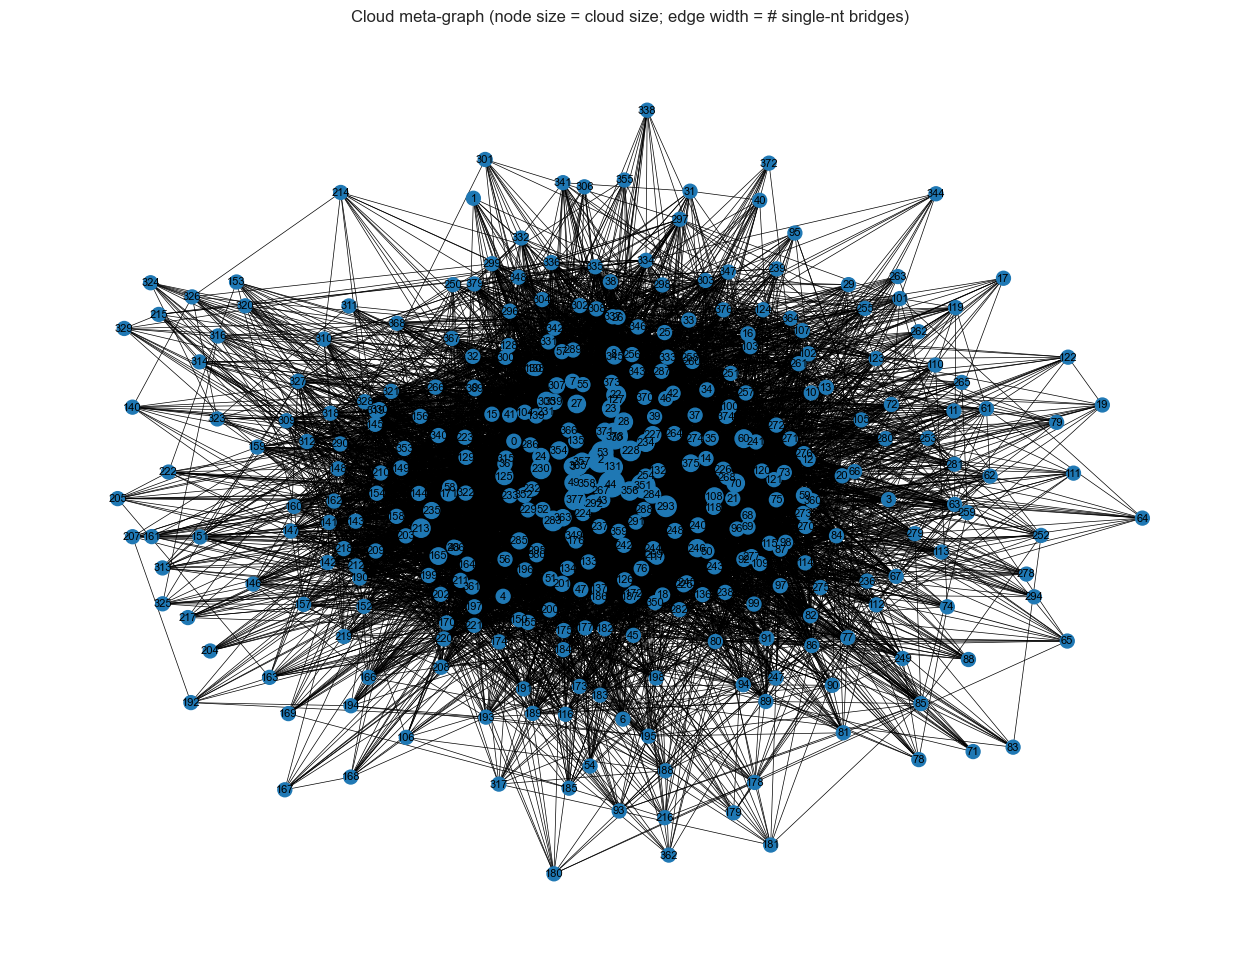

In [19]:
# Draw the figures
plot_cloud_meta_graph(H_cloud)

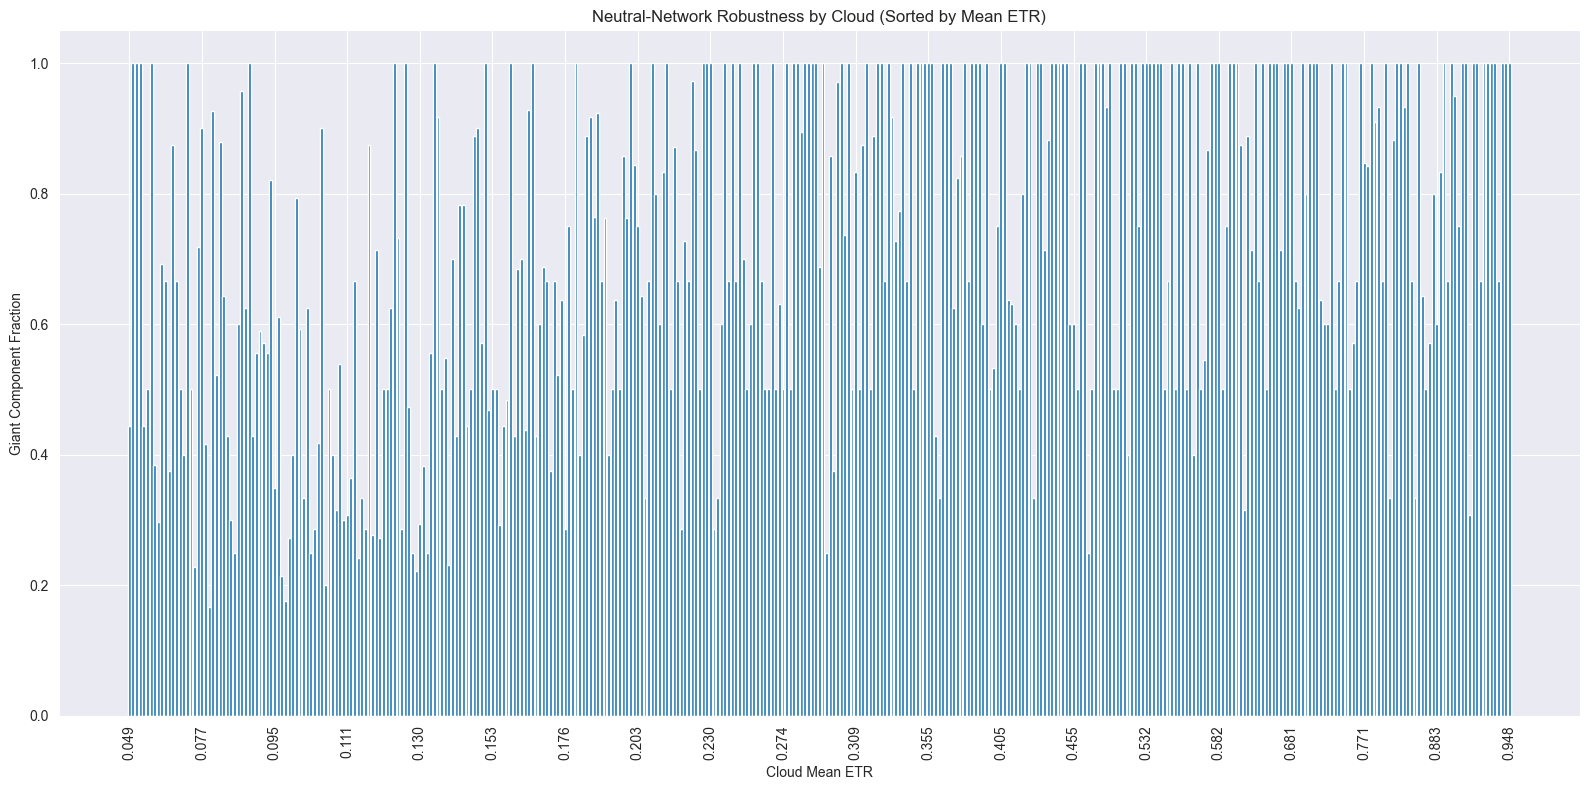

In [20]:
plot_giant_component_fraction(intra_df, savepath="giant_component_fraction.eps")

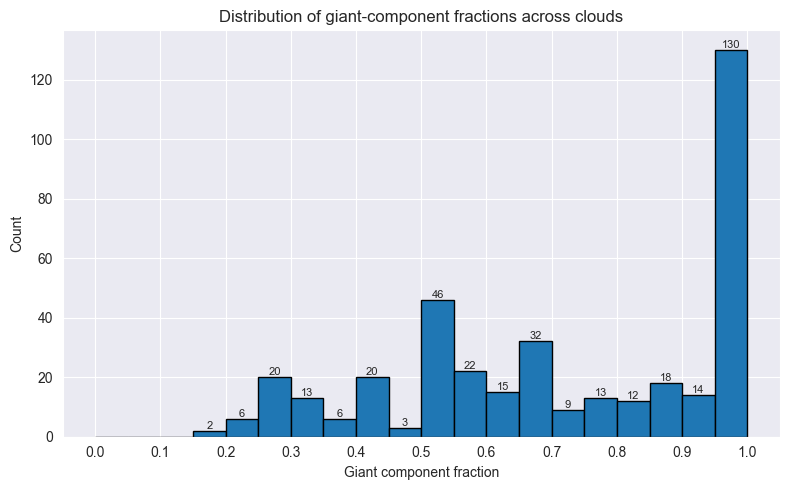

In [21]:
plot_gcf_histogram(intra_df, savepath="gcf_histogram.eps")

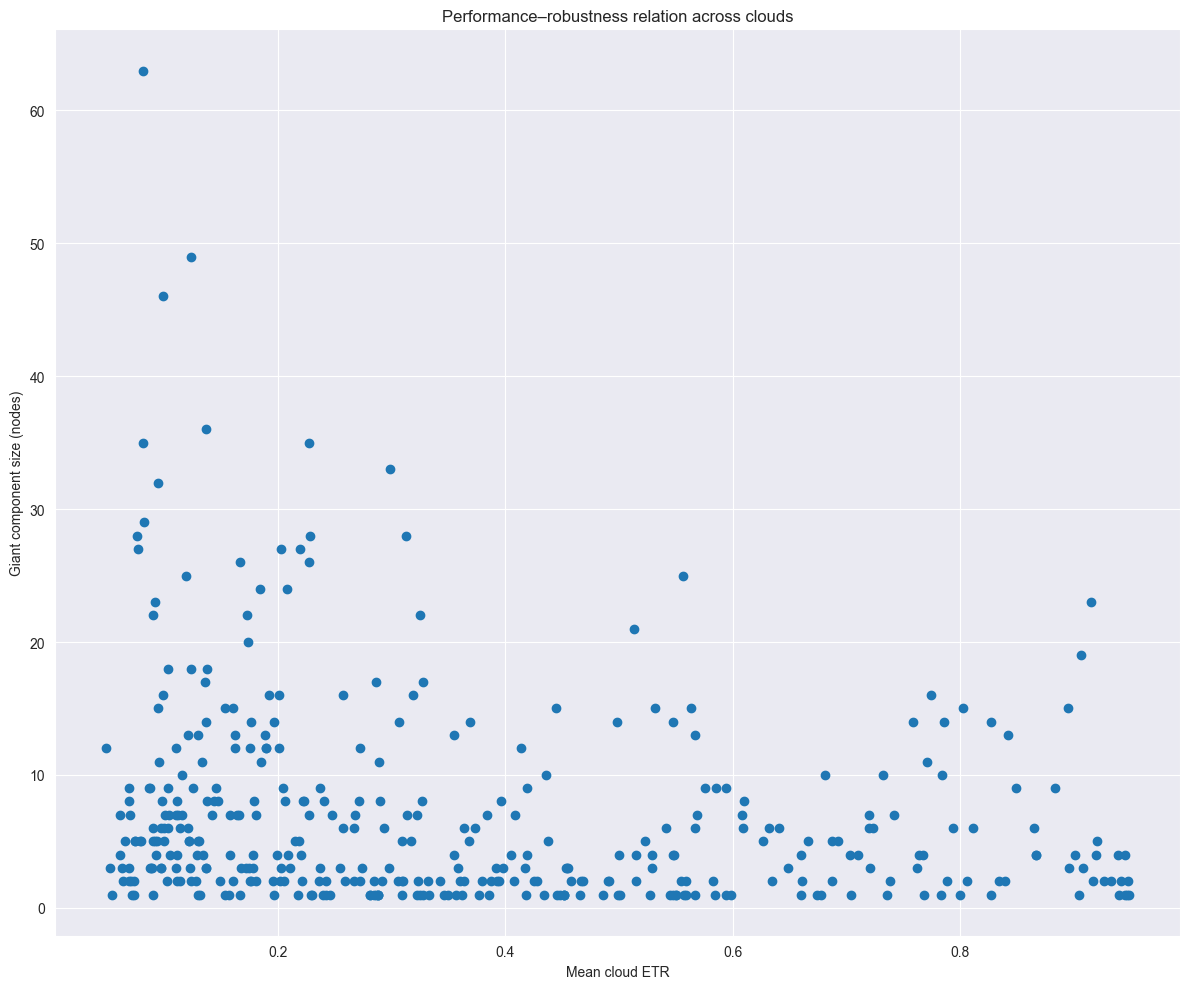

In [22]:
plot_cloud_mean_etr_vs_giant(intra_df)

In [23]:
order = intra_df.sort_values("mean_cloud_etr")["cloud"].tolist()

In [24]:
def build_bridge_matrix(meta_edges_df: pd.DataFrame, clouds=None, value="bridge_count") -> pd.DataFrame:
    """
    Construct a symmetric (cloud x cloud) matrix from meta_edges_df.

    Parameters
    ----------
    meta_edges_df : DataFrame
        Must contain columns: 'cloud_u', 'cloud_v', and the chosen 'value' column:
          - 'bridge_count'           (# of Hamming-1 bridges between clouds)
          - 'mean_abs_delta_etr'     (mean |ΔETR| across those bridges)
    clouds : list or None
        Optional explicit ordering of cloud labels for rows/cols. If None, inferred.
    value : str
        Which metric to place into the matrix ('bridge_count' or 'mean_abs_delta_etr').

    Returns
    -------
    DataFrame
        Symmetric matrix indexed by cloud labels.
        Diagonal is 0 for 'bridge_count', NaN for 'mean_abs_delta_etr'.
    """
    required_cols = {"cloud_u", "cloud_v", value}
    missing = required_cols - set(meta_edges_df.columns)
    if missing:
        raise ValueError(f"meta_edges_df missing columns: {missing}")

    # Determine the set/order of clouds
    if clouds is None:
        clouds = sorted(set(meta_edges_df["cloud_u"]) | set(meta_edges_df["cloud_v"]))

    mat = pd.DataFrame(np.nan, index=clouds, columns=clouds, dtype=float)

    # Diagonal convention
    if value == "bridge_count":
        np.fill_diagonal(mat.values, 0.0)
    else:
        # keep NaN on diagonal for mean |ΔETR|
        pass

    # Fill both [u, v] and [v, u]
    for _, row in meta_edges_df.iterrows():
        a, b, v = row["cloud_u"], row["cloud_v"], row[value]
        if a in mat.index and b in mat.columns:
            mat.loc[a, b] = v
            mat.loc[b, a] = v

    return mat

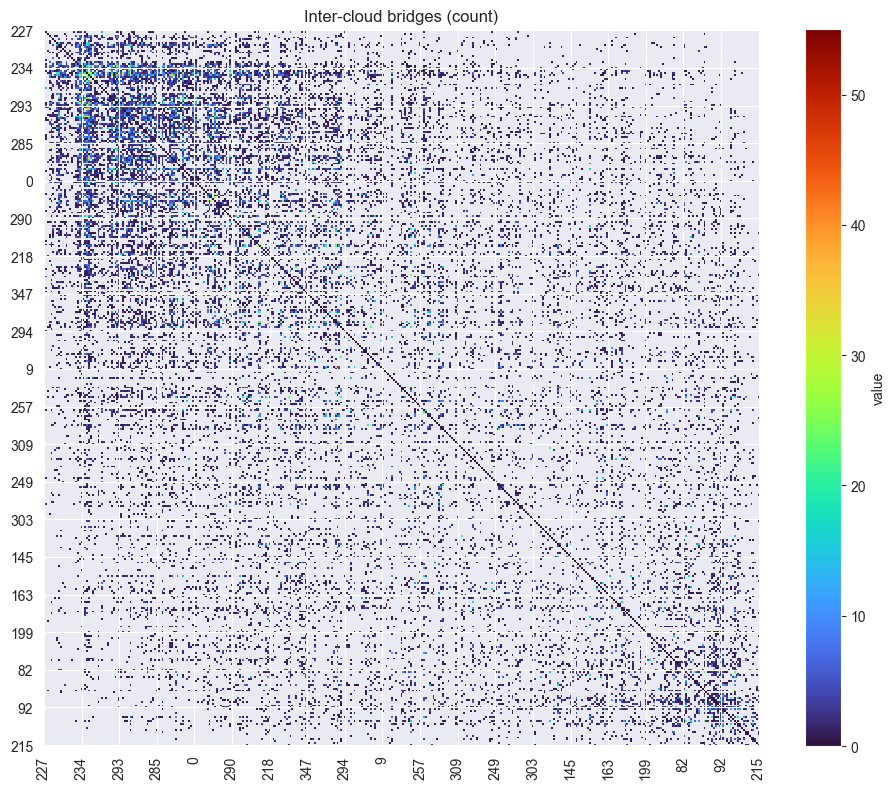

In [25]:
bridge_count_mat = build_bridge_matrix(meta_edges_df, value="bridge_count")
plot_heatmap(bridge_count_mat.loc[order, order], "Inter-cloud bridges (count)", savepath="bridge_count_heatmap.eps")

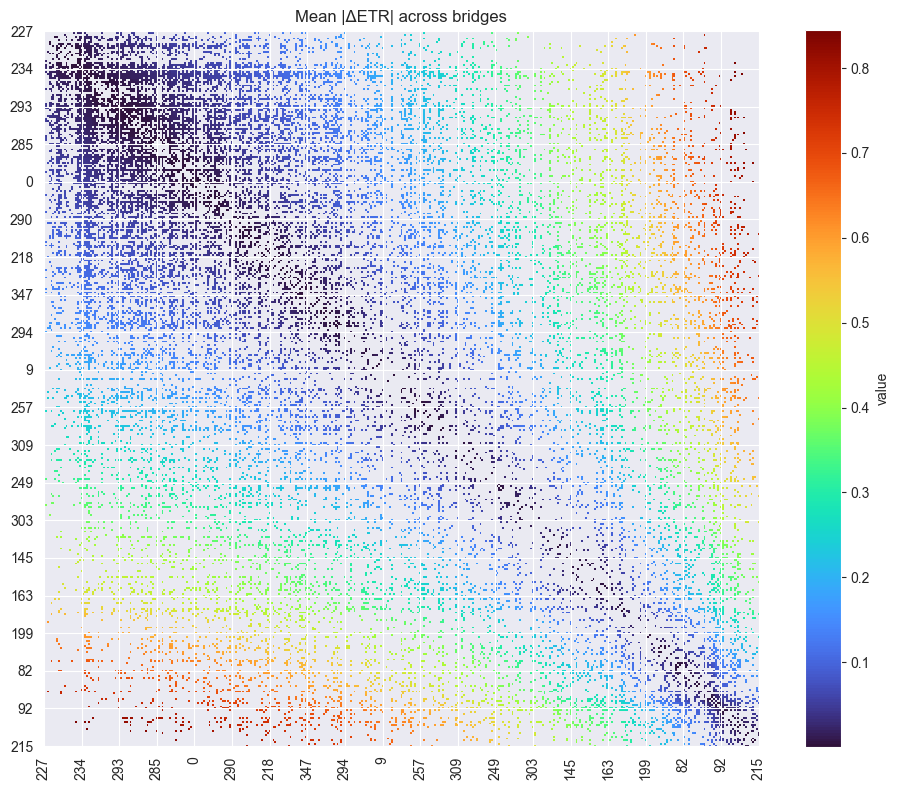

In [26]:
delta_mat = build_bridge_matrix(meta_edges_df, value="mean_abs_delta_etr")
plot_heatmap(delta_mat.loc[order, order], "Mean |ΔETR| across bridges", savepath="mean_abs_delta_etr_heatmap.eps")

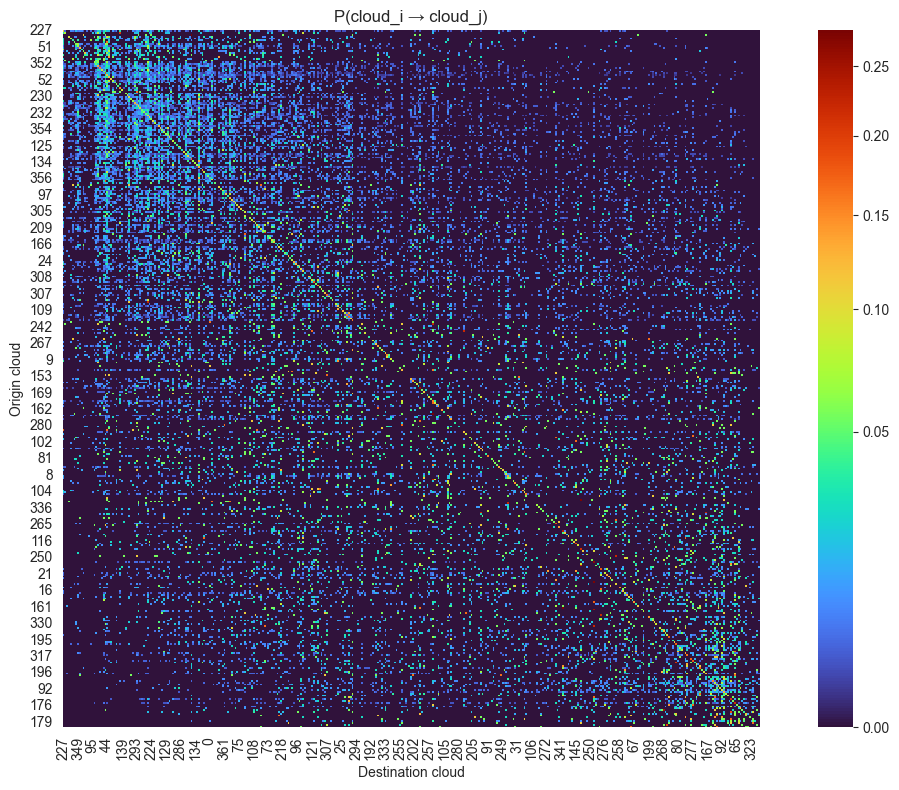

In [27]:
plot_Tprob_heatmap(T_prob_df.loc[order, order], title="P(cloud_i → cloud_j)", savepath="T_prob_heatmap.eps")

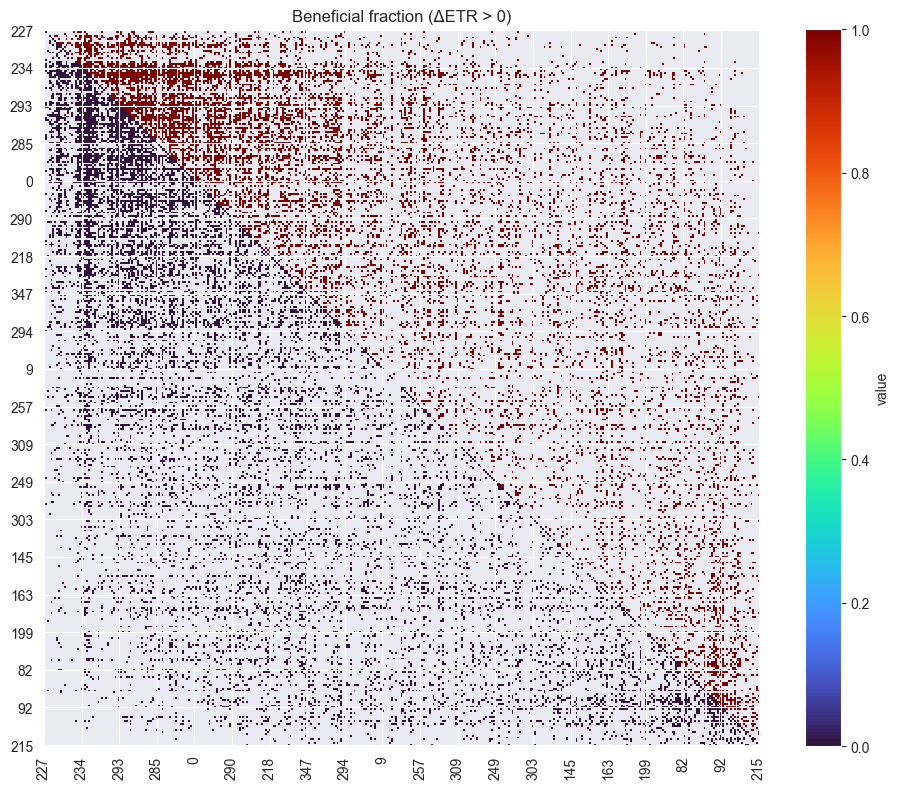

In [28]:
plot_heatmap(T_benef_df.loc[order, order], "Beneficial fraction (ΔETR > 0)")